## turbineSiting (*geo3D*)

[**Gouda Wind Facility**](https://en.wikipedia.org/wiki/Gouda_Wind_Facility), Western Cape South Africa 

Educational-scale wind-flow and turbine siting workflow using [***geo3D***](https://adriankriger.github.io/geo3D/) and [**OpenFOAM**](https://www.openfoam.com).

Turbine characteristic and dimensions correspond to the 3D model.
Mast locations are based on real-world positions.
The full wind facility is not reproduced.

In [1]:
#load the magic

%matplotlib inline
import os
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
import json
import geojson

from cjio import cityjson

import openSiting

import matplotlib.pyplot as plt

In [2]:
# With the new 0.10.x syntax:
with open('25mTerrain3DTurbines.json', 'r') as f:
    cm = cityjson.reader(f)

In [3]:
print(cm)

CityJSON version = 2.0.0
EPSG = 32734
bbox = [ 310447.860 6311554.695 41.250 322952.684 6324059.519 1487.015 ]
=== CityObjects ===
|-- TINRelief (1)
|-- OtherConstruction (46)
materials = False
textures = False


In [4]:
# Extract data directly from the dictionary we built
data = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # We only want Buildings for this GDF, skipping the terrain (TINRelief)
    if obj_data['type'] == 'OtherConstruction':
        row = {'id': obj_id}
        row.update(obj_data.get('attributes', {}))
        data.append(row)

df = pd.DataFrame(data)
df.head(2)

,id,class,mastID,X,Y,lat,lon,manufacturer,model,rated_power_kw,...,cut_in_ms,rated_ms,cut_out_ms,iec_class,generator_type,gearbox_type,gearbox_stages,onshore,offshore,ground_height
0,mastID_01,wind_turbine,01,314606.424760,6.319671e+06,-33.2632,19.0321,Vestas,V100-2.0,2000,...,3.0,12.0,22.0,llb,DFIG,spur_planetary,3,True,False,61.93
1,mastID_02,wind_turbine,02,314887.003852,6.319834e+06,-33.2632,19.0321,Vestas,V100-2.0,2000,...,3.0,12.0,22.0,llb,DFIG,spur_planetary,3,True,False,64.87


In [5]:
#df = cm.to_dataframe()
#- remove the first feature: the terrain
#df = df[1:]    

#- harvest the crs
theinfo = cm.get_info()
crs = theinfo[1]

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['X'], df['Y']), 
    crs=crs[7:]
)
gdf.head(2)

,id,class,mastID,X,Y,lat,lon,manufacturer,model,rated_power_kw,...,rated_ms,cut_out_ms,iec_class,generator_type,gearbox_type,gearbox_stages,onshore,offshore,ground_height,geometry
0,mastID_01,wind_turbine,01,314606.424760,6.319671e+06,-33.2632,19.0321,Vestas,V100-2.0,2000,...,12.0,22.0,llb,DFIG,spur_planetary,3,True,False,61.93,POINT (314606.425 6319670.986)
1,mastID_02,wind_turbine,02,314887.003852,6.319834e+06,-33.2632,19.0321,Vestas,V100-2.0,2000,...,12.0,22.0,llb,DFIG,spur_planetary,3,True,False,64.87,POINT (314887.004 6319833.699)


In [6]:
#gdf.head(2)
bbox = theinfo[2]
extent = [float(bbox[9:18]), float(bbox[20:30]), float(bbox[39:48]), float(bbox[50:60])]

extent
#[315173.9466398532, 6316285.467382115, 318226.3425625299, 6319328.635225126]

[310447.86, 6311554.69, 322952.68, 6324059.51]

In [7]:
Su_inlet = 6.9      # m/s
Su_deg = 210        # @ 600 hour/year | https://www.meteoblue.com/en/weather/historyclimate/climatemodelled/gouda_south-africa_3367553

In [8]:
#- harvest the data
#start = time.time()


summer100m, center_x_utm, center_y_utm  = openSiting.load_openfoam_vtk(file_name='hubHeight100.vtk', wind_deg=Su_deg, extent=extent, radius=3000.0)

#end = time.time()
#print('runtime:', str(timedelta(seconds=(end - start))))

summer100m.head(3)

,X,Y,Z,U,V,u_mag,k
0,318949.887200,6.315882e+06,207.023667,1.896250,5.861301,6.188255,0.163885
1,318722.366118,6.315616e+06,179.505500,2.787343,6.502094,7.085704,0.095679
2,318769.104469,6.315697e+06,185.309000,2.652424,6.429324,6.970201,0.108383


In [9]:
len(summer100m)#.Z.values

41091

### Plot

**Wake at Hub height (100m)** *--how do the turbines influence each other?*   |   we interogate at the dominant wind direction: SSW (600 hour/year)

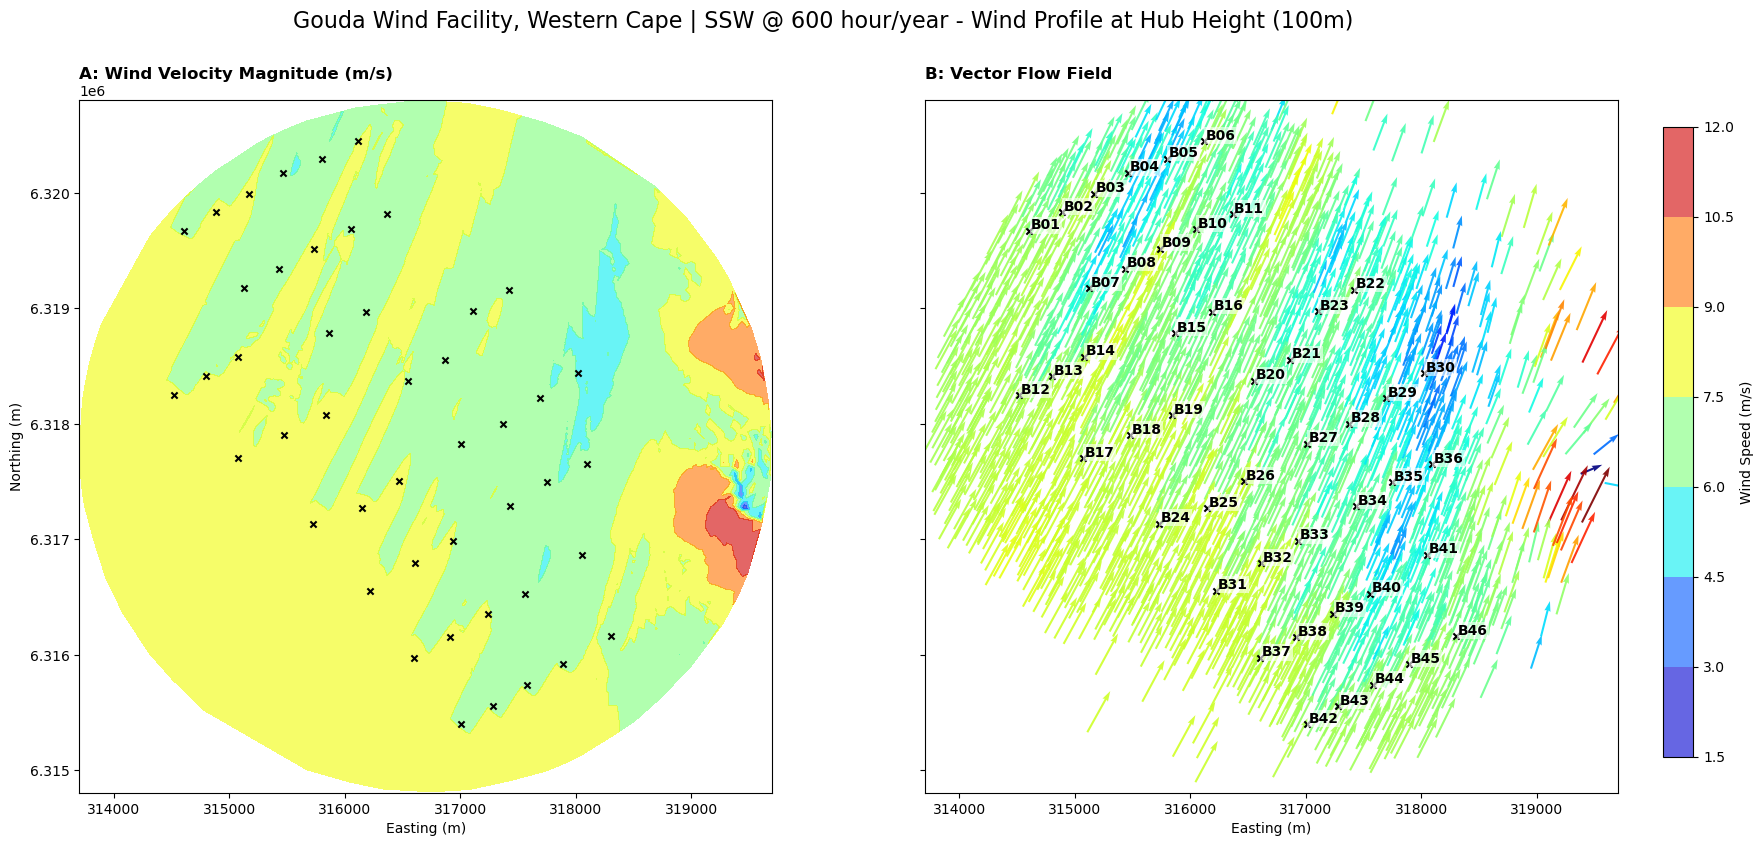

In [10]:
fig, axes =  openSiting.plot_wind_analysis(summer100m, gdf, center_x_utm, center_y_utm, radius=3000, title_suffix="Wind Profile at Hub Height (100m)")

plt.show()

**Power Curve at a specific mast**

In [11]:
def build_slice_dataframe(raw_mesh_df, gdf_masts):
    """
    Groups the raw 3D point data by finding the closest physical turbine mast.
    
    raw_mesh_df: Your dataframe with columns ['X', 'Y', 'Z', 'u_mag']
    gdf_masts: Your GeoDataFrame containing ['mastID', 'local_x', 'local_y']
    """
    matched_rows = []
    gdf_masts['X'] = gdf_masts.geometry.x
    gdf_masts['Y'] = gdf_masts.geometry.y
    
    # Loop through every 3D slice row in your raw dataset
    for _, point in raw_mesh_df.iterrows():
        px, py = point['X'], point['Y']
        
        # Calculate Euclidean distance from this point to all 12 turbine masts
        distances = np.sqrt(
            (gdf_masts['X'] - px)**2 + 
            (gdf_masts['Y'] - py)**2
        )
        
        # Find the index of the nearest physical mast
        closest_idx = distances.idxmin()
        closest_mast = gdf_masts.loc[closest_idx, 'mastID']
        
        # Keep the point and tag it with the correct Mast ID
        point_data = point.to_dict()
        point_data['mastID'] = closest_mast
        matched_rows.append(point_data)
        
    # This output is the 'df_slice' used in the plotting step!
    df_slice = pd.DataFrame(matched_rows)
    return df_slice

df_slice = build_slice_dataframe(summer100m, gdf)
df_slice.head(2)

,X,Y,Z,U,V,u_mag,k,mastID
0,318949.887200,6.315882e+06,207.023667,1.896250,5.861301,6.188255,0.163885,46
1,318722.366118,6.315616e+06,179.505500,2.787343,6.502094,7.085704,0.095679,46


In [12]:
mastID34 = df_slice[df_slice['mastID'] == '34']

In [13]:
#- power curve @ mast

def calculate_Vestas_power(u_hub, rho=1.225):
    """
    Calculates the electric power output (kW) specifically for a Vestas V100-2.0 MW.
    Based on manufacturer operational constraints: 3.0 m/s cut-in, 12 m/s rated, 22.0 m/s cut-out.
    """
    # Pull constants directly from your turbine specifications
    cut_in = 3.0
    rated_speed = 12
    cut_out = 22.0
    rated_power_kw = 2000.0
    swept_area = 7854.0
    
    # 1. Extreme Weather / Sub-operational Conditions
    if u_hub < cut_in or u_hub >= cut_out:
        return 0.0
    
    # 2. Flat Rated Capacity Plateau
    elif rated_speed <= u_hub < cut_out:
        return rated_power_kw
    
    # 3. Cubic Aerodynamic Extraction Zone
    else:
        # Step-wise empirical Cp curve adaptation for calculate_Acciona_power active pitch control
        # This prevents over-estimating yield right before the rated limit.
        if u_hub < 7.0:
            cp = 0.44  # Maximum efficiency in clean, low-to-mid breeze
        elif u_hub < 10.0:
            cp = 0.41  # Active pitch optimization starts turning the blades
        else:
            cp = 0.33  # Bleeding aerodynamic torque to safely approach the 2MW ceiling
            
        power_watts = 0.5 * rho * swept_area * cp * (u_hub ** 3)
        power_kw = power_watts / 1000.0
        
        # Guard rail to clamp mathematical variance to mechanical limits
        return min(power_kw, rated_power_kw)

# Assuming your vertical coordinate column is named 'Z'
hub_height = 95.0

# Find the row closest to 100 for this specific turbine location
hub_row = mastID34.iloc[(mastID34['Z'] - hub_height).abs().argsort()[:1]]
u_hub = hub_row['u_mag'].values[0]

# Run it through your power curve
power_kw = calculate_Vestas_power(u_hub)
power_kw

723.1275713888125

### Relative Power

We look at relative power along the wind direction

In [14]:

# --- 1. SAMPLE INITIAL DATA STRUCTURE ---
# Let's assume 'df_slice' contains your extracted profile data with columns:
# ['mastID', 'X', 'Y', 'Z', 'u_mag']

# Find the mean velocity magnitude for each unique mast across its 70m-130m slice
turbine_summary = []
for mast_id, group in df_slice.groupby('mastID'):
    # Calculate the Rotor Equivalent Wind Speed (REWS) or simple mean
    u_mean = group['u_mag'].mean() 
    # Grab the horizontal coordinate to figure out row order
    x_coord = group['X'].mean() 
    y_coord = group['Y'].mean() 

    turbine_summary.append({
        'mastID': f"B{int(mast_id):02d}", # Formats to 'B01', 'B02' matching your plot style
        'X': x_coord,
        'Y': y_coord,
        'u_hub': u_mean
    })

df_array = pd.DataFrame(turbine_summary)

# Sort from front to back along the wind direction (West to East / Low X to High X)
df_array = df_array.sort_values(by='X').reset_index(drop=True)
df_array.head(2)

,mastID,X,Y,u_hub
0,B12,314153.332766,6.318080e+06,7.851962
1,B01,314477.642473,6.319406e+06,7.704349


In [15]:
#- define your incoming wind direction 
wind_rad = np.radians(Su_deg)

#- create the unit vector pointing in the direction the wind flows
wind_vector = np.array([np.cos(wind_rad), np.sin(wind_rad)])

#- project the (X, Y) coordinates onto the wind vector axis
# This calculates the true distance along the wind's travel path
df_array['streamwise_distance'] = df_array.apply(
    lambda row: np.dot(np.array([row['X'], row['Y']]), wind_vector), axis=1
)

#- sort from front (windward entry) to back (leeward exit)
df_array = df_array.sort_values(by='streamwise_distance', ascending=False).reset_index(drop=True)

#- calculate power using calculate_Vestas_power function
df_array['power_kw'] = df_array['u_hub'].apply(calculate_Vestas_power)

#- define P1 (the leading upstream turbine at index 0 after sorting)
p1_power = df_array.loc[0, 'power_kw']

#- calculate the relative power ratio (Pn / P1)
df_array['Pn_P1'] = df_array['power_kw'] / p1_power
df_array.head(2)

,mastID,X,Y,u_hub,streamwise_distance,power_kw,Pn_P1
0,B12,314153.332766,6.318080e+06,7.851962,-3.431105e+06,954.806648,1.000000
1,B17,314687.113208,6.317274e+06,8.087003,-3.431164e+06,1043.142515,1.092517


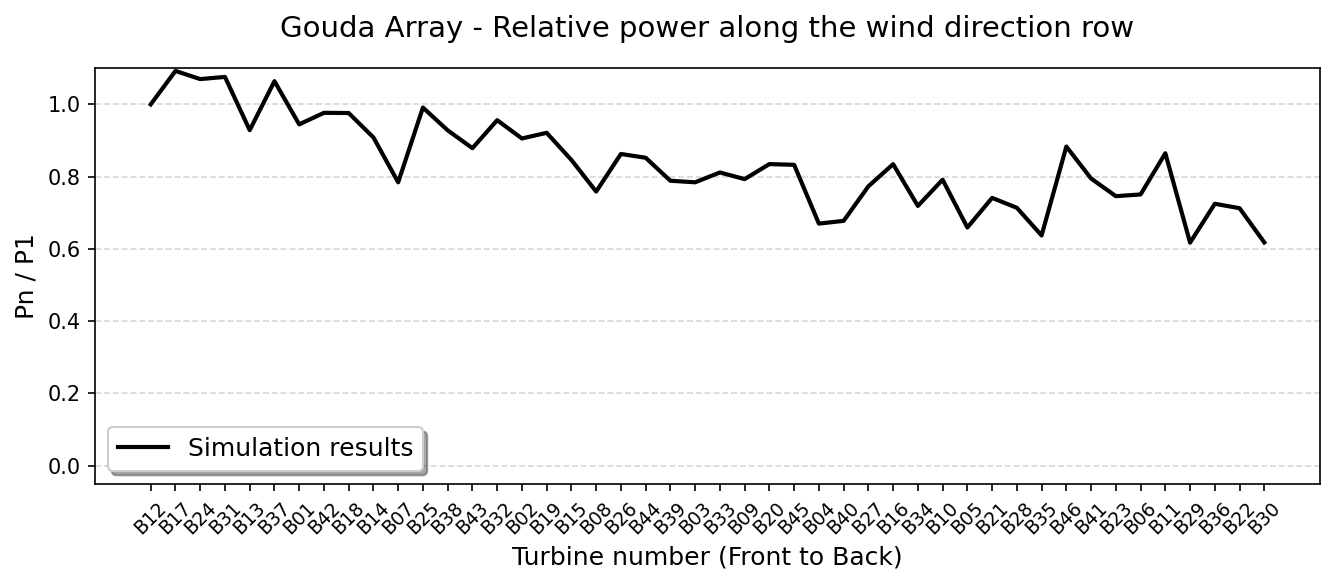

In [16]:
plt.figure(figsize=(9, 4), dpi=150)

# Plot your simulation trend line
plt.plot(df_array['mastID'], df_array['Pn_P1'], 
         color='black', marker='', linestyle='-', linewidth=2, label='Simulation results')

# Add comparison placeholders if you want to plot explicit validation points
#plt.scatter(validation_masts, validation_ratios, color='#377eb8', s=60, label='Nygaard et al. 2020')
plt.xticks(rotation=45, fontsize=9)

# Match layout styling
plt.title('Gouda Array - Relative power along the wind direction row', fontsize=14, pad=15)
plt.xlabel('Turbine number (Front to Back)', fontsize=12)
plt.ylabel('Pn / P1', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.1) # Adapts nicely to show the classic ~20-30% dropoff
plt.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()